# Contoh kasus: alur ekstraksi fitur CQT dan deteksi *onset*

Notebook ini menelusuri **satu berkas audio** dari gelombang mentah sampai titik *onset* terdeteksi,
dengan setiap besaran dihitung secara eksplisit. Tujuannya melengkapi Bab III dengan angka nyata,
bukan sekadar rumus.

**Berkas contoh:** `training/validations/normal_sustain/normal_sustain-10.ogg` — sampel yang sama
dengan yang sudah dipakai pada Bab IV (anotasi *ground truth*-nya adalah Tabel 4.8), sehingga
penjelasan Bab III dan hasil Bab IV merujuk objek yang identik.

Pertanyaan yang dijawab, berurutan:

| # | Pertanyaan | Bagian |
|---|---|---|
| 1 | Berapa panjang *window* dan berapa intervalnya? | 2, 3 |
| 2 | Bagaimana CQT dihitung dari rumusnya? | 3, 4 |
| 3 | Matriks fitur apa yang masuk ke CNN? | 5 |
| 4 | Apa yang dihasilkan ODF? | 6 |
| 5 | Bagaimana *peak picking* memakai parameter $\delta$? | 7 |

Seluruh parameter diambil persis dari `training/notebooks/training/cqt-extraction.ipynb`
(ekstraksi fitur) dan `training/notebooks/onset-latest/onset-grid.ipynb` (deteksi *onset*),
sehingga tidak ada nilai yang khusus dibuat untuk notebook ini.

In [1]:
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import scipy.ndimage
from IPython.display import Markdown, display

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/method-example"),
    Path("training/notebooks/method-example").resolve(),
]
HERE = next(
    p for p in _CANDIDATES
    if (p.parent.parent / "validations" / "normal_sustain.npz").is_file()
)
TRAINING = HERE.parent.parent
VALID = TRAINING / "validations"

# --- ekstraksi fitur (cqt-extraction.ipynb) ---
AUDIO_SAMPLE_RATE = 48_000       # Hz
AUDIO_MIN_DURATION = 2           # detik
CQT_HOP_LENGTH = 512             # sampel antar frame
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36         # 3 bin per semiton
CQT_FEATURE_BINS = CQT_BINS_PER_OCTAVE * CQT_OCTAVES          # 216
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)  # 188
CQT_FMIN = float(librosa.note_to_hz("C1"))

# --- deteksi onset (onset-grid.ipynb) ---
ODF_KW = {
    "spectral-flux": {"lag": 1, "max_size": 1},
    "superflux": {"lag": 2, "max_size": 3},
}
PEAK_PICK = {"pre_max": 30, "post_max": 1, "pre_avg": 100, "post_avg": 1, "wait": 30}
ONSET_NFFT = 2048                # default librosa.onset.onset_strength, dipakai pada koreksi lag
DELTAS = [0.10, 0.20, 0.30, 0.40, 0.50]

SAMPLE_AUDIO = VALID / "normal_sustain" / "normal_sustain-10.ogg"
SAMPLE_ANNOT = SAMPLE_AUDIO.with_suffix(".txt")
assert SAMPLE_AUDIO.is_file() and SAMPLE_ANNOT.is_file(), SAMPLE_AUDIO

frame_ms = CQT_HOP_LENGTH / AUDIO_SAMPLE_RATE * 1000.0

display(pd.DataFrame([
    ("Sample rate", f"{AUDIO_SAMPLE_RATE:,} Hz"),
    ("Hop length", f"{CQT_HOP_LENGTH} sampel"),
    ("Interval antar frame", f"{frame_ms:.4f} ms"),
    ("Bin per oktaf", f"{CQT_BINS_PER_OCTAVE} (= {CQT_BINS_PER_OCTAVE // 12} bin/semiton)"),
    ("Jumlah oktaf", CQT_OCTAVES),
    ("Jumlah bin frekuensi", CQT_FEATURE_BINS),
    ("Durasi minimum", f"{AUDIO_MIN_DURATION} detik"),
    ("Jumlah frame fitur", CQT_FEATURE_FRAMES),
    ("Frekuensi terendah", f"{CQT_FMIN:.4f} Hz (C1)"),
    ("Berkas contoh", SAMPLE_AUDIO.name),
], columns=["Parameter", "Nilai"]).set_index("Parameter"))

,Nilai
Parameter,
Sample rate,"48,000 Hz"
Hop length,512 sampel
Interval antar frame,10.6667 ms
Bin per oktaf,36 (= 3 bin/semiton)
Jumlah oktaf,6
Jumlah bin frekuensi,216
Durasi minimum,2 detik
Jumlah frame fitur,188
Frekuensi terendah,32.7032 Hz (C1)


## 1. Kasus contoh

Berkas audio dimuat ulang pada 48 kHz mono. Anotasi `.txt` berisi tiga kolom
(`awal`, `akhir`, `akor`) dan menjadi acuan *ground truth* untuk evaluasi deteksi *onset*.

In [2]:
y, sr = librosa.load(SAMPLE_AUDIO, sr=AUDIO_SAMPLE_RATE, mono=True)

annot = pd.read_csv(
    SAMPLE_ANNOT, sep=r"\s+", header=None,
    names=["mulai (detik)", "selesai (detik)", "akor"],
)
annot.index = pd.RangeIndex(1, len(annot) + 1, name="Indeks onset")

display(Markdown(
    f"**Audio:** {y.size:,} sampel @ {sr:,} Hz = **{y.size / sr:.3f} detik**  \n"
    f"**Anotasi:** {len(annot)} onset *ground truth*"
))
display(annot)

**Audio:** 607,680 sampel @ 48,000 Hz = **12.660 detik**  
**Anotasi:** 10 onset *ground truth*

,mulai (detik),selesai (detik),akor
Indeks onset,,,
1,0.101,0.862,G:min
2,1.294,2.003,G:min
3,2.469,3.174,G:dim
4,3.646,4.422,G#:dim
5,4.835,5.847,C#:min
6,6.347,7.119,A:min
7,7.566,8.618,C:dim
8,8.936,9.872,A:min
9,10.268,11.135,F#:dim


## 2. *Framing*: interval antar analisis

Sinyal tidak dianalisis sekaligus, melainkan pada titik-titik waktu berjarak tetap sebesar
*hop length* $H = 512$ sampel. Interval antar *frame* karena itu bernilai

$$\Delta t = \frac{H}{f_s} = \frac{512}{48\,000} = 0{,}0106\overline{6}\ \text{detik} = 10{,}67\ \text{ms}$$

Jumlah *frame* yang dihasilkan dari audio berdurasi $T$ detik (dengan `center=True`, yaitu
sinyal di-*pad* di kedua ujung sehingga *frame* ke-$n$ berpusat di $nH$) adalah

$$N_{\text{frame}} = \left\lfloor \frac{T \cdot f_s}{H} \right\rfloor + 1$$

Untuk *dataset* pelatihan yang setiap klipnya dibatasi $T = 2$ detik, jumlah *frame* yang
dipakai sebagai lebar matriks fitur ditetapkan

$$N_{\text{frame}} = \mathrm{round}\!\left(\frac{2 \times 48\,000}{512}\right) = \mathrm{round}(187{,}5) = 188$$

**Catatan penting:** $H$ hanya menentukan *jarak antar* analisis, **bukan** panjang *window*
analisisnya. Pada CQT panjang *window* berbeda-beda untuk setiap bin frekuensi — inilah yang
dibahas pada bagian 3.

In [3]:
duration_s = y.size / sr
n_frames_file = int(np.floor(y.size / CQT_HOP_LENGTH)) + 1

display(pd.DataFrame([
    ("Hop length $H$", f"{CQT_HOP_LENGTH} sampel"),
    ("Interval antar frame $H/f_s$", f"{CQT_HOP_LENGTH / sr * 1000:.4f} ms"),
    ("Laju frame $f_s/H$", f"{sr / CQT_HOP_LENGTH:.3f} frame/detik"),
    ("Durasi berkas contoh", f"{duration_s:.3f} detik"),
    ("Jumlah frame berkas contoh", f"floor({y.size:,}/{CQT_HOP_LENGTH}) + 1 = {n_frames_file}"),
    ("Jumlah frame klip 2 detik", f"round(2x{sr:,}/{CQT_HOP_LENGTH}) = {CQT_FEATURE_FRAMES}"),
], columns=["Besaran", "Nilai"]).set_index("Besaran"))

,Nilai
Besaran,
Hop length $H$,512 sampel
Interval antar frame $H/f_s$,10.6667 ms
Laju frame $f_s/H$,93.750 frame/detik
Durasi berkas contoh,12.660 detik
Jumlah frame berkas contoh,"floor(607,680/512) + 1 = 1187"
Jumlah frame klip 2 detik,"round(2x48,000/512) = 188"


## 3. *Constant-Q Transform*: rumus dan panjang *window*

### 3.1 Frekuensi tengah tiap bin

Bin CQT tersusun secara geometris (logaritmik), bukan linear seperti STFT:

$$f_k = f_{\min} \cdot 2^{\,k/B}, \qquad k = 0, 1, \dots, K-1$$

dengan $f_{\min} = 32{,}7032$ Hz (nada C1), $B = 36$ bin per oktaf, dan
$K = B \times 6 = 216$ bin. Karena $B = 36 = 3 \times 12$, setiap semiton diwakili
**3 bin**, sehingga deviasi penalaan sampai $\pm\frac{1}{3}$ semiton masih terwakili.

### 3.2 Faktor kualitas $Q$

"*Constant-Q*" berarti rasio frekuensi tengah terhadap lebar pita bernilai tetap untuk
semua bin:

$$Q = \frac{f_k}{\Delta f_k} = \frac{1}{2^{1/B} - 1} = \frac{1}{2^{1/36} - 1} \approx 51{,}44$$

### 3.3 Panjang *window* tiap bin — inti perbedaan dengan STFT

Karena $Q$ tetap, panjang *window* analisis **berbanding terbalik dengan frekuensi**:

$$N_k = \frac{Q \cdot f_s}{f_k}\ \text{sampel} \qquad\Longleftrightarrow\qquad
  \tau_k = \frac{Q}{f_k}\ \text{detik}$$

Jadi tidak ada satu angka "panjang *window*". Bin terendah memakai *window* yang panjang
(resolusi frekuensi tinggi, resolusi waktu rendah) dan bin tertinggi memakai *window*
yang pendek (sebaliknya). Perhitungan pada sel berikut menunjukkan rentangnya.

### 3.4 Rumus transformasinya

Untuk *frame* yang berpusat di sampel $t$:

$$X^{\text{CQT}}(k, t) = \sum_{n=0}^{N_k - 1} w_k[n]\; x\!\left[n + t - \tfrac{N_k}{2}\right]
  \; e^{-j 2\pi Q n / N_k}$$

dengan $w_k[\cdot]$ adalah *window* Hann sepanjang $N_k$. Keluarannya kompleks, lalu diambil
magnitudonya dan dikonversi ke desibel relatif terhadap nilai maksimum:

$$S(k,t) = 20 \log_{10}\frac{\left|X^{\text{CQT}}(k,t)\right|}{\max_{k,t}\left|X^{\text{CQT}}(k,t)\right|}$$

In [4]:
Q = 1.0 / (2 ** (1 / CQT_BINS_PER_OCTAVE) - 1)
k_all = np.arange(CQT_FEATURE_BINS)
f_k = CQT_FMIN * 2 ** (k_all / CQT_BINS_PER_OCTAVE)
N_k = Q * AUDIO_SAMPLE_RATE / f_k          # sampel
tau_k = N_k / AUDIO_SAMPLE_RATE            # detik

display(Markdown(
    f"$Q = 1/(2^{{1/36}}-1) = **{Q:.4f}**$ &nbsp;&nbsp;|&nbsp;&nbsp; "
    f"rentang bin: {f_k[0]:.2f} Hz ({librosa.hz_to_note(f_k[0])}) "
    f"sampai {f_k[-1]:.2f} Hz ({librosa.hz_to_note(f_k[-1])})"
))

rows = [0, 36, 72, 108, 144, 180, 215]
tabel_bin = pd.DataFrame({
    "Bin $k$": rows,
    "Nada": [librosa.hz_to_note(f_k[i]) for i in rows],
    "$f_k$ (Hz)": f_k[rows].round(2),
    "$N_k$ (sampel)": N_k[rows].round(0).astype(int),
    "$\\tau_k$ (ms)": (tau_k[rows] * 1000).round(1),
    "$\\tau_k$ / hop": (N_k[rows] / CQT_HOP_LENGTH).round(1),
}).set_index("Bin $k$")
display(tabel_bin)

display(Markdown(
    f"**Window terpanjang (bin 0, C1): {tau_k[0]:.4f} detik.** "
    f"Nilai inilah yang menentukan durasi minimum klip: sebuah klip harus lebih panjang dari "
    f"{tau_k[0]:.3f} s agar bin terendah terisi penuh, sehingga batas **{AUDIO_MIN_DURATION} detik** "
    f"yang dipakai pada penelitian ini memberi margin {AUDIO_MIN_DURATION - tau_k[0]:.3f} s.  \n"
    f"**Window terpendek (bin 215, {librosa.hz_to_note(f_k[-1])}): {tau_k[-1] * 1000:.2f} ms** "
    f"— sekitar {N_k[-1] / CQT_HOP_LENGTH:.1f}x hop, jadi *frame* yang berdekatan tetap saling tumpang tindih."
))

$Q = 1/(2^{1/36}-1) = **51.4386**$ &nbsp;&nbsp;|&nbsp;&nbsp; rentang bin: 32.70 Hz (C1) sampai 2053.09 Hz (C7)

,Nada,$f_k$ (Hz),$N_k$ (sampel),$\tau_k$ (ms),$\tau_k$ / hop
Bin $k$,,,,,
0,C1,32.70,75499,1572.9,147.5
36,C2,65.41,37749,786.4,73.7
72,C3,130.81,18875,393.2,36.9
108,C4,261.63,9437,196.6,18.4
144,C5,523.25,4719,98.3,9.2
180,C6,1046.50,2359,49.2,4.6
215,C7,2053.09,1203,25.1,2.3


**Window terpanjang (bin 0, C1): 1.5729 detik.** Nilai inilah yang menentukan durasi minimum klip: sebuah klip harus lebih panjang dari 1.573 s agar bin terendah terisi penuh, sehingga batas **2 detik** yang dipakai pada penelitian ini memberi margin 0.427 s.  
**Window terpendek (bin 215, C7): 25.05 ms** — sekitar 2.3x hop, jadi *frame* yang berdekatan tetap saling tumpang tindih.

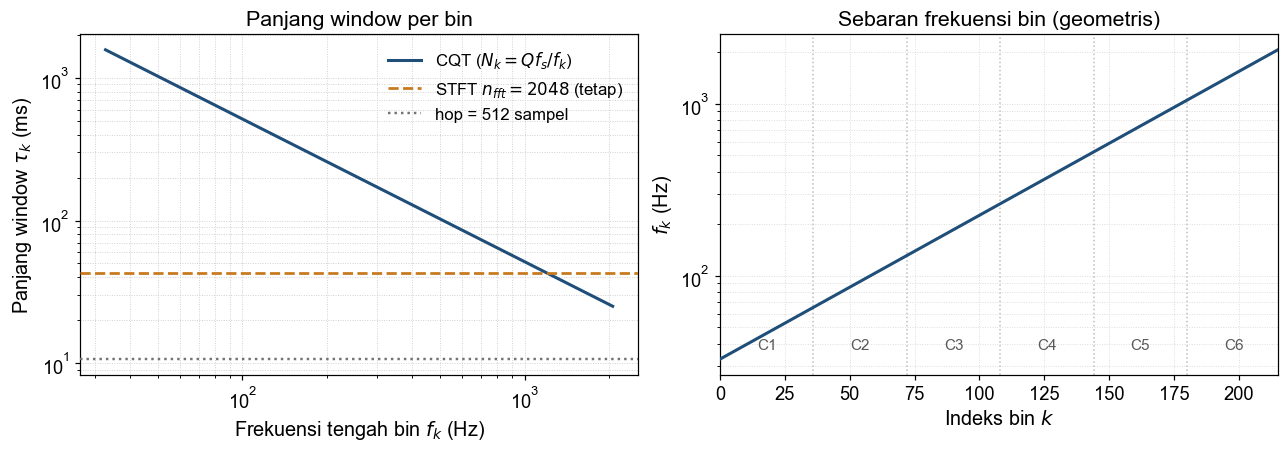

In [5]:
import matplotlib.pyplot as plt

NAVY, ACCENT, FILL = "#1f4e79", "#c8791e", "#d6e3f0"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 14,
    "legend.fontsize": 11, "legend.frameon": False, "figure.dpi": 110,
})

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0), layout="constrained")

ax = axes[0]
ax.plot(f_k, tau_k * 1000, color=NAVY, lw=2.0, zorder=3, label="CQT ($N_k = Q f_s / f_k$)")
ax.axhline(2048 / AUDIO_SAMPLE_RATE * 1000, color=ACCENT, ls="--", lw=1.8,
           zorder=3, label="STFT $n_{fft}=2048$ (tetap)")
ax.axhline(CQT_HOP_LENGTH / AUDIO_SAMPLE_RATE * 1000, color="0.45", ls=":", lw=1.6,
           zorder=3, label="hop = 512 sampel")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Frekuensi tengah bin $f_k$ (Hz)")
ax.set_ylabel("Panjang window $\\tau_k$ (ms)")
ax.set_title("Panjang window per bin")
ax.set_axisbelow(True)
ax.grid(True, which="both", ls=":", lw=0.6, color="0.8")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(k_all, f_k, color=NAVY, lw=2.0, zorder=3)
for oct_i in range(CQT_OCTAVES + 1):
    ax.axvline(oct_i * CQT_BINS_PER_OCTAVE, color="0.75", ls=":", lw=1.0, zorder=1)
ax.set_yscale("log")
ax.set_xlabel("Indeks bin $k$")
ax.set_ylabel("$f_k$ (Hz)")
ax.set_title("Sebaran frekuensi bin (geometris)")
ax.set_xlim(0, CQT_FEATURE_BINS - 1)
ax.set_axisbelow(True)
ax.grid(True, which="both", ls=":", lw=0.6, color="0.85")
for oct_i in range(CQT_OCTAVES):
    ax.text(oct_i * CQT_BINS_PER_OCTAVE + 18, f_k[0] * 1.15,
            f"C{oct_i + 1}", ha="center", fontsize=10, color="0.35")

plt.show()

## 4. Perhitungan CQT pada berkas contoh

Pemanggilan yang persis dipakai pada `cqt-extraction.ipynb`, lalu magnitudo dan konversi desibel.

In [6]:
C_complex = librosa.cqt(
    y=y, sr=sr,
    fmin=CQT_FMIN,
    n_bins=CQT_FEATURE_BINS,
    bins_per_octave=CQT_BINS_PER_OCTAVE,
    hop_length=CQT_HOP_LENGTH,
    window="hann",
)
C_mag = np.abs(C_complex)                                  # magnitudo
S_db = librosa.amplitude_to_db(C_mag, ref=np.max)          # desibel relatif maksimum

display(pd.DataFrame([
    ("Keluaran librosa.cqt", f"{C_complex.shape}, dtype {C_complex.dtype}"),
    ("Setelah np.abs", f"{C_mag.shape}, rentang [{C_mag.min():.3e}, {C_mag.max():.3e}]"),
    ("Setelah amplitude_to_db", f"{S_db.shape}, rentang [{S_db.min():.2f}, {S_db.max():.2f}] dB"),
    ("Interpretasi dimensi", f"{S_db.shape[0]} bin frekuensi x {S_db.shape[1]} frame waktu"),
    ("Durasi terwakili", f"{S_db.shape[1] * CQT_HOP_LENGTH / sr:.3f} detik"),
], columns=["Tahap", "Hasil"]).set_index("Tahap"))

# Satu frame di tengah akor pertama (G:min, 0,101-0,862 s) -> puncak energi = nada penyusun akor
t_probe = 0.45
frame_probe = int(round(t_probe * sr / CQT_HOP_LENGTH))
col = S_db[:, frame_probe]
peak_bins = [k for k in range(1, CQT_FEATURE_BINS - 1)
             if col[k] > col[k - 1] and col[k] >= col[k + 1] and col[k] > -35]
top = sorted(peak_bins, key=lambda k: col[k], reverse=True)[:6]

display(Markdown(
    f"**Frame {frame_probe}** (t = {frame_probe * CQT_HOP_LENGTH / sr:.3f} s, "
    f"di dalam akor `{annot.iloc[0]['akor']}`) — puncak energi terkuat:"
))
display(pd.DataFrame({
    "Bin $k$": top,
    "$f_k$ (Hz)": f_k[top].round(2),
    "Nada terdekat": [librosa.hz_to_note(f_k[k]) for k in top],
    "Energi (dB)": col[top].round(2),
}).set_index("Bin $k$"))

,Hasil
Tahap,
Keluaran librosa.cqt,"(216, 1187), dtype complex64"
Setelah np.abs,"(216, 1187), rentang [5.888e-06, 3.842e+00]"
Setelah amplitude_to_db,"(216, 1187), rentang [-80.00, 0.00] dB"
Interpretasi dimensi,216 bin frekuensi x 1187 frame waktu
Durasi terwakili,12.661 detik


**Frame 42** (t = 0.448 s, di dalam akor `G:min`) — puncak energi terkuat:

,$f_k$ (Hz),Nada terdekat,Energi (dB)
Bin $k$,,,
129,392.00,G4,-8.440000
114,293.66,D4,-10.080000
102,233.08,A♯3,-11.740000
150,587.33,D5,-16.760000
93,196.00,G3,-17.639999
138,466.16,A♯4,-20.330000


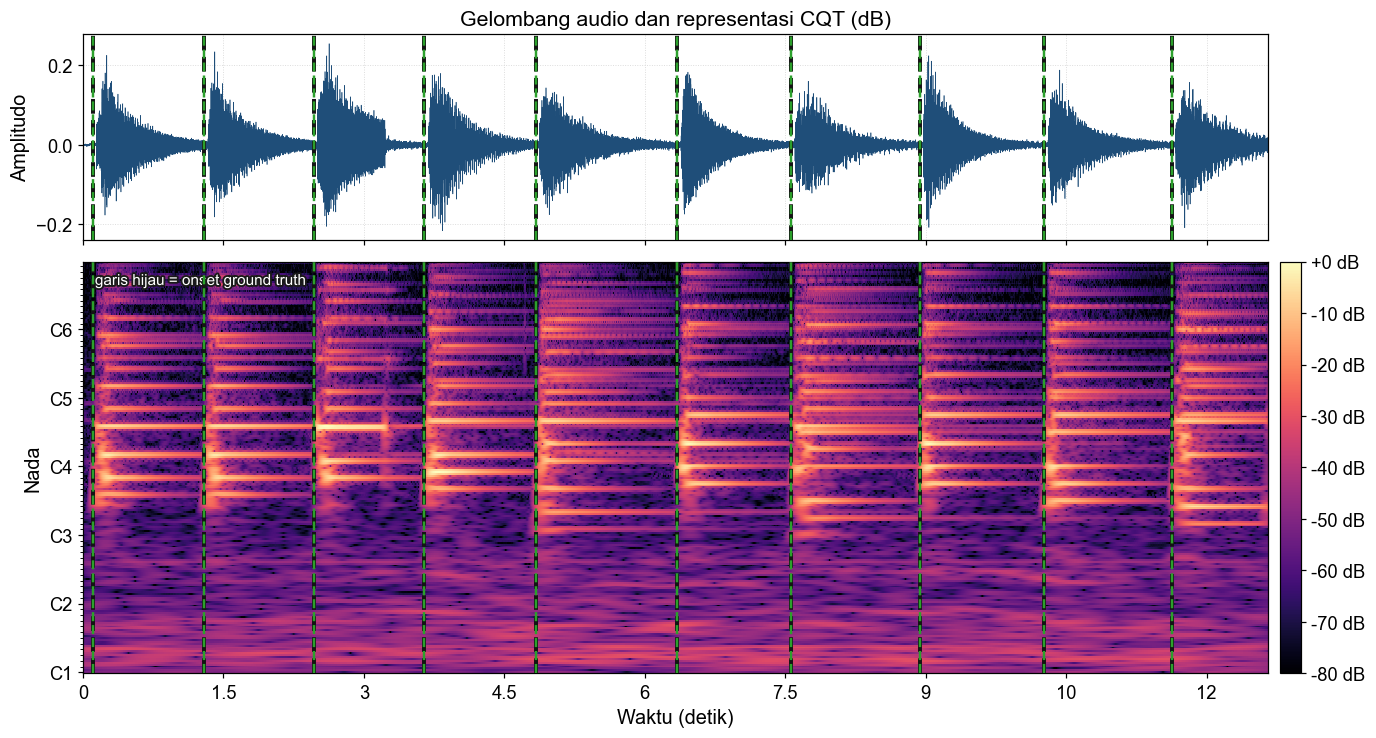

In [7]:
import librosa.display
import matplotlib.patheffects as pe

fig, axes = plt.subplots(2, 1, figsize=(12.4, 6.6), layout="constrained",
                         sharex=True, height_ratios=[1, 2])

t_axis = np.arange(y.size) / sr
axes[0].plot(t_axis, y, color=NAVY, lw=0.4)
axes[0].set_ylabel("Amplitudo")
axes[0].set_title("Gelombang audio dan representasi CQT (dB)")
axes[0].set_xlim(0, duration_s)
axes[0].set_axisbelow(True)
axes[0].grid(True, ls=":", lw=0.6, color="0.85")

img = librosa.display.specshow(
    S_db, x_axis="time", y_axis="cqt_note", sr=sr,
    hop_length=CQT_HOP_LENGTH, fmin=CQT_FMIN,
    bins_per_octave=CQT_BINS_PER_OCTAVE, ax=axes[1],
)
for _, ev in annot.iterrows():
    for ax in axes:
        ax.axvline(ev["mulai (detik)"], color="0.08", ls="--", lw=2.6, zorder=4)
        ax.axvline(ev["mulai (detik)"], color="#2ca02c", ls="--", lw=1.6, zorder=5)
axes[1].set_xlabel("Waktu (detik)")
axes[1].set_ylabel("Nada")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB", pad=0.01)
axes[1].text(0.01, 0.97, "garis hijau = onset ground truth", transform=axes[1].transAxes,
             va="top", fontsize=10, color="white",
             path_effects=[pe.Stroke(linewidth=2.4, foreground="0.1"), pe.Normal()])
plt.show()

## 5. Matriks fitur $216 \times 188$ yang masuk ke CNN

CNN tidak menerima seluruh berkas, melainkan **satu segmen berdurasi 2 detik**. Pada
*dataset* pelatihan setiap berkas memang sudah berupa klip akor tunggal; pada tahap deteksi
akor, segmen diambil mulai dari titik *onset*.

Fungsi `preprocess()` pada `cqt-extraction.ipynb` menyeragamkan lebar matriks:

```python
if cqt.shape[1] < CQT_FEATURE_FRAMES:      # audio < 2 detik
    cqt = np.pad(cqt, ((0, 0), (0, pad_width)), mode="constant")   # zero padding di kanan
else:                                       # audio > 2 detik
    cqt = cqt[:, :CQT_FEATURE_FRAMES]                              # truncate
```

sehingga keluarannya **selalu** $216 \times 188$, lalu diberi dimensi kanal menjadi
$216 \times 188 \times 1$ sebagai masukan lapisan konvolusi.

/home/seya/code/chord-detection/.venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=750
  warnings.warn(


,Hasil
Tahap,
Segmen diambil,0.101 - 2.101 detik (akor G:min)
Sampel audio segmen,"96,000"
CQT sebelum preprocess,"(216, 188)"
Setelah preprocess,"(216, 188)"
Masukan CNN,"(216, 188, 1)"


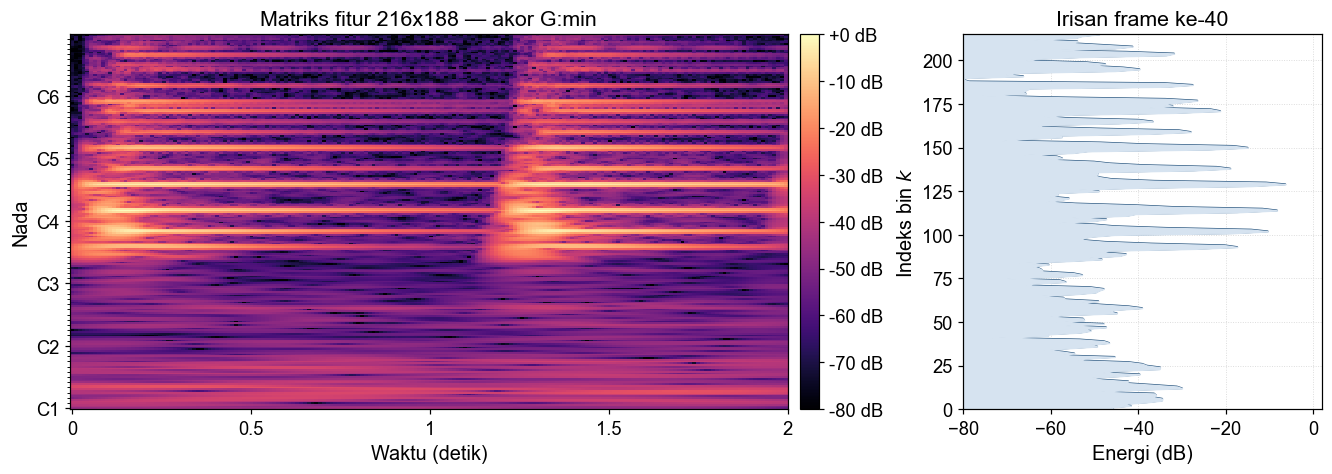

In [8]:
def preprocess(cqt: np.ndarray) -> np.ndarray:
    """Sama persis dengan cqt-extraction.ipynb."""
    if cqt.shape[1] < CQT_FEATURE_FRAMES:
        pad_width = CQT_FEATURE_FRAMES - cqt.shape[1]
        return np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode="constant")
    return cqt[:, :CQT_FEATURE_FRAMES]


# Segmen 2 detik yang dimulai pada onset pertama (0,101 s) -> akor G:min
seg_start_s = float(annot.iloc[0]["mulai (detik)"])
seg_start_sample = int(round(seg_start_s * sr))
seg_audio = y[seg_start_sample:seg_start_sample + AUDIO_MIN_DURATION * sr]

seg_cqt = librosa.amplitude_to_db(
    np.abs(librosa.cqt(
        y=seg_audio, sr=sr, fmin=CQT_FMIN, n_bins=CQT_FEATURE_BINS,
        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH, window="hann",
    )),
    ref=np.max,
)
seg_feature = preprocess(seg_cqt)

display(pd.DataFrame([
    ("Segmen diambil", f"{seg_start_s:.3f} - {seg_start_s + AUDIO_MIN_DURATION:.3f} detik (akor {annot.iloc[0]['akor']})"),
    ("Sampel audio segmen", f"{seg_audio.size:,}"),
    ("CQT sebelum preprocess", f"{seg_cqt.shape}"),
    ("Setelah preprocess", f"{seg_feature.shape}"),
    ("Masukan CNN", f"{seg_feature.shape + (1,)}"),
], columns=["Tahap", "Hasil"]).set_index("Tahap"))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), layout="constrained",
                         width_ratios=[2, 1])
img = librosa.display.specshow(
    seg_feature, x_axis="time", y_axis="cqt_note", sr=sr,
    hop_length=CQT_HOP_LENGTH, fmin=CQT_FMIN,
    bins_per_octave=CQT_BINS_PER_OCTAVE, ax=axes[0],
)
axes[0].set_title(f"Matriks fitur {seg_feature.shape[0]}x{seg_feature.shape[1]} — akor {annot.iloc[0]['akor']}")
axes[0].set_xlabel("Waktu (detik)"); axes[0].set_ylabel("Nada")
fig.colorbar(img, ax=axes[0], format="%+2.0f dB", pad=0.01)

probe_col = seg_feature[:, 40]
axes[1].plot(probe_col, k_all, color=NAVY, lw=1.2)
axes[1].fill_betweenx(k_all, -80, probe_col, color=FILL, zorder=2)
axes[1].set_xlabel("Energi (dB)"); axes[1].set_ylabel("Indeks bin $k$")
axes[1].set_title("Irisan frame ke-40")
axes[1].set_ylim(0, CQT_FEATURE_BINS - 1); axes[1].set_xlim(-80, 2)
axes[1].set_axisbelow(True); axes[1].grid(True, ls=":", lw=0.6, color="0.85")
plt.show()

## 6. *Onset Detection Function* (ODF)

### 6.1 Apa yang dihasilkan ODF

ODF **meringkas matriks CQT $216 \times T$ menjadi satu deret waktu sepanjang $T$**. Nilainya
besar ketika energi spektral *naik* mendadak — indikasi nada baru dipetik — dan mendekati nol
selama nada bertahan atau meluruh. Jadi keluaran ODF bukan titik *onset*, melainkan
*kurva kekuatan onset* yang masih perlu diambil puncaknya (bagian 7).

### 6.2 *Spectral flux*

Selisih maju antar *frame* pada matriks dB, dibuang bagian negatifnya (hanya kenaikan energi
yang relevan), lalu dirata-ratakan pada sumbu frekuensi:

$$\mathrm{SF}[t] = \frac{1}{K}\sum_{k=0}^{K-1} \max\bigl(0,\; S(k,\,t) - S(k,\,t-\mu)\bigr)$$

dengan $\mu = 1$ (`lag=1`).

### 6.3 *SuperFlux*

Böck & Widmer (2013) menambah dua hal untuk menekan *false positive* akibat vibrato dan
peluruhan nada: **jeda diperlebar** menjadi $\mu = 2$ *frame*, dan pembanding diambil dari
*maximum filter* selebar $m = 3$ bin pada sumbu **frekuensi**:

$$\tilde{S}(k,t) = \max_{|i| \le \lfloor m/2 \rfloor} S(k+i,\,t)$$

$$\mathrm{SuF}[t] = \frac{1}{K}\sum_{k=0}^{K-1} \max\bigl(0,\; S(k,\,t) - \tilde{S}(k,\,t-\mu)\bigr)$$

Karena $B = 36$ (3 bin per semiton), $m = 3$ tepat setara toleransi $\pm\frac{1}{3}$ semiton —
cukup untuk mengabaikan getaran *pitch* kecil, tetapi tidak cukup untuk menutupi pergantian akor.

### 6.4 Kompensasi *lag*

Selisih berjeda $\mu$ memperpendek deret sebanyak $\mu$ *frame*, dan `center=True` menggeser
sumbu waktu sebesar $n_{\text{fft}} / 2H$ *frame*. Keduanya dikompensasi dengan *zero padding*
di awal sebesar $\mu + n_{\text{fft}}/(2H) = \mu + 2$ *frame*, lalu deret dipotong kembali ke
panjang $T$ agar sejajar dengan sumbu waktu CQT.

In [9]:
def odf_manual(S: np.ndarray, lag: int, max_size: int) -> dict:
    """Implementasi ulang librosa.onset.onset_strength, tahap demi tahap."""
    ref = S if max_size == 1 else scipy.ndimage.maximum_filter1d(S, max_size, axis=-2)
    diff = S[..., lag:] - ref[..., :-lag]          # selisih berjeda lag
    rect = np.maximum(0.0, diff)                   # buang penurunan energi
    agg = rect.mean(axis=-2)                       # rata-rata pada sumbu frekuensi
    pad = lag + ONSET_NFFT // (2 * CQT_HOP_LENGTH)  # kompensasi lag + center
    env = np.pad(agg, (pad, 0))[: S.shape[-1]]     # padding lalu potong ke panjang T
    return {"ref": ref, "diff": diff, "rect": rect, "agg": agg, "pad": pad, "env": env}


steps, envelopes = {}, {}
check_rows = []
for name, kw in ODF_KW.items():
    st = odf_manual(S_db, **kw)
    lib = librosa.onset.onset_strength(
        S=S_db, sr=sr, hop_length=CQT_HOP_LENGTH, **kw
    )
    steps[name], envelopes[name] = st, st["env"]
    check_rows.append({
        "ODF": name,
        "lag $\\mu$": kw["lag"],
        "max_size $m$": kw["max_size"],
        "padding (frame)": st["pad"],
        "panjang keluaran": st["env"].size,
        "maks ODF": round(float(st["env"].max()), 4),
        "identik dgn librosa": bool(np.array_equal(st["env"], lib)),
    })

display(pd.DataFrame(check_rows).set_index("ODF"))
assert all(r["identik dgn librosa"] for r in check_rows), "reimplementasi tidak cocok"

# Contoh angka pada satu frame di dekat onset kedua (1,294 s)
f_demo = int(round(1.294 * sr / CQT_HOP_LENGTH))
st = steps["superflux"]
lag = ODF_KW["superflux"]["lag"]
j = f_demo - st["pad"]                       # indeks pada deret sebelum padding
display(Markdown(
    f"**Contoh perhitungan SuperFlux, frame {f_demo}** (t = {f_demo * CQT_HOP_LENGTH / sr:.3f} s, "
    f"dekat onset ke-2 pada 1,294 s):  \n"
    f"- membandingkan $S(\\cdot,\\,{j + lag})$ dengan max-filter $\\tilde{{S}}(\\cdot,\\,{j})$  \n"
    f"- bin dengan kenaikan energi (rect > 0): **{int((st['rect'][:, j] > 0).sum())}** dari {CQT_FEATURE_BINS}  \n"
    f"- kenaikan terbesar: **{st['rect'][:, j].max():.2f} dB** pada bin {int(st['rect'][:, j].argmax())}  \n"
    f"- rata-rata seluruh bin = nilai ODF: **{st['agg'][j]:.4f}**"
))

,lag $\mu$,max_size $m$,padding (frame),panjang keluaran,maks ODF,identik dgn librosa
ODF,,,,,,
spectral-flux,1,1,3,1187,3.9077,True
superflux,2,3,4,1187,5.3997,True


**Contoh perhitungan SuperFlux, frame 121** (t = 1.291 s, dekat onset ke-2 pada 1,294 s):  
- membandingkan $S(\cdot,\,119)$ dengan max-filter $\tilde{S}(\cdot,\,117)$  
- bin dengan kenaikan energi (rect > 0): **71** dari 216  
- kenaikan terbesar: **15.52 dB** pada bin 110  
- rata-rata seluruh bin = nilai ODF: **1.2059**

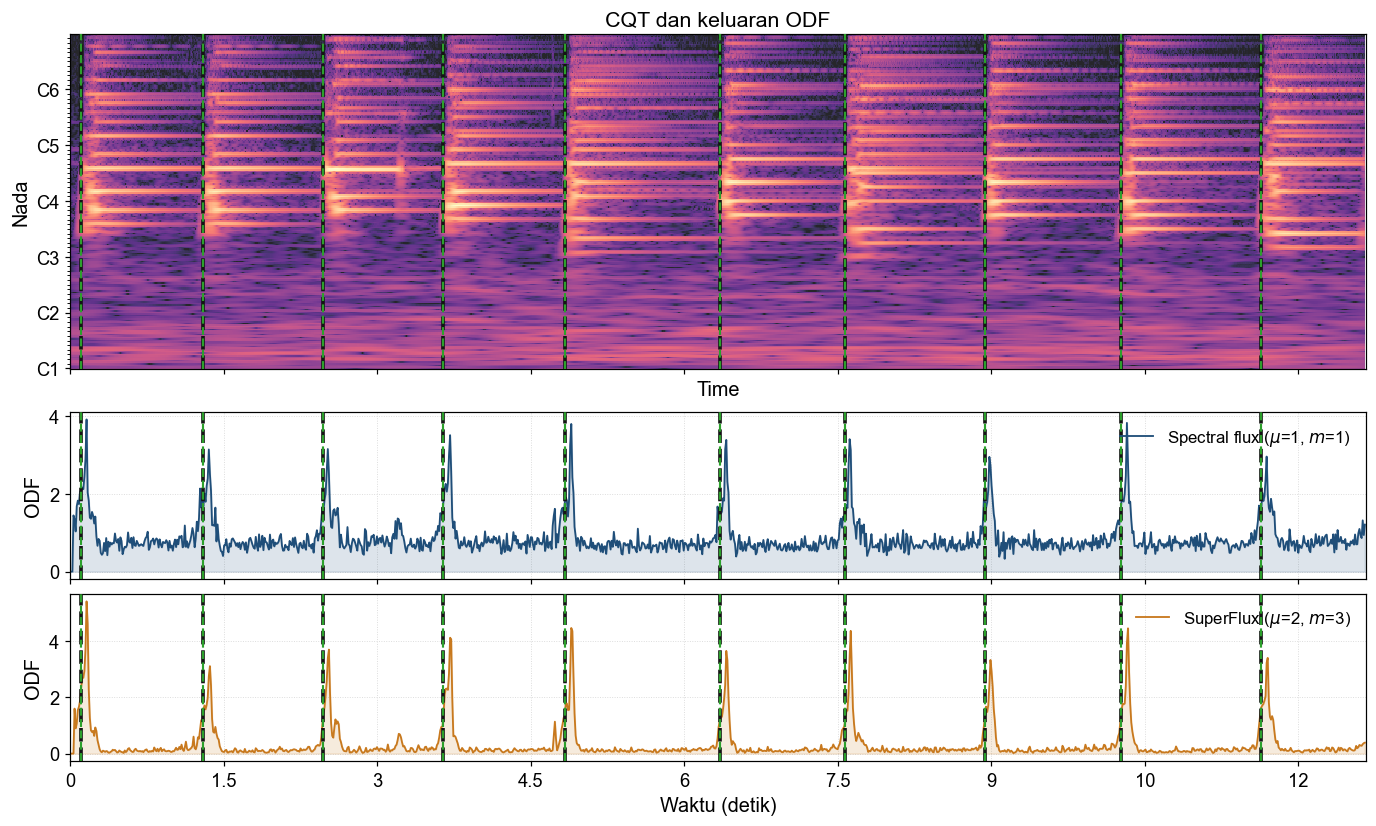

,panjang,min,maks,rerata,frame bernilai 0
ODF,,,,,
spectral-flux,1187,0.0,3.9077,0.8738,3
superflux,1187,0.0,5.3997,0.3495,4


In [10]:
env_t = librosa.times_like(envelopes["superflux"], sr=sr, hop_length=CQT_HOP_LENGTH)
ODF_STYLE = {
    "spectral-flux": dict(color=NAVY, lw=1.2, label="Spectral flux ($\\mu$=1, $m$=1)"),
    "superflux": dict(color=ACCENT, lw=1.2, label="SuperFlux ($\\mu$=2, $m$=3)"),
}

fig, axes = plt.subplots(3, 1, figsize=(12.4, 7.4), layout="constrained", sharex=True,
                         height_ratios=[2, 1, 1])

librosa.display.specshow(
    S_db, x_axis="time", y_axis="cqt_note", sr=sr, hop_length=CQT_HOP_LENGTH,
    fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE, ax=axes[0], alpha=0.85,
)
axes[0].set_ylabel("Nada"); axes[0].set_title("CQT dan keluaran ODF")

for ax, name in zip(axes[1:], ODF_KW):
    ax.plot(env_t, envelopes[name], **ODF_STYLE[name])
    ax.fill_between(env_t, 0, envelopes[name], color=ODF_STYLE[name]["color"], alpha=0.15)
    ax.set_ylabel("ODF")
    ax.legend(loc="upper right")
    ax.set_axisbelow(True); ax.grid(True, ls=":", lw=0.6, color="0.85")

for _, ev in annot.iterrows():
    for ax in axes:
        ax.axvline(ev["mulai (detik)"], color="0.08", ls="--", lw=2.4, zorder=4)
        ax.axvline(ev["mulai (detik)"], color="#2ca02c", ls="--", lw=1.4, zorder=5)

axes[-1].set_xlabel("Waktu (detik)")
axes[-1].set_xlim(0, duration_s)
plt.show()

display(pd.DataFrame([
    {
        "ODF": name,
        "panjang": envelopes[name].size,
        "min": round(float(envelopes[name].min()), 4),
        "maks": round(float(envelopes[name].max()), 4),
        "rerata": round(float(envelopes[name].mean()), 4),
        "frame bernilai 0": int((envelopes[name] == 0).sum()),
    }
    for name in ODF_KW
]).set_index("ODF"))

## 7. *Peak picking* dan parameter $\delta$

### 7.1 Normalisasi

Sebelum ambang diterapkan, kurva ODF dinormalisasi ke rentang $[0, 1]$ agar $\delta$ punya
arti yang sama untuk berkas dengan tingkat energi berbeda:

$$x[t] = \frac{\mathrm{ODF}[t] - \min_t \mathrm{ODF}}{\max_t \mathrm{ODF} - \min_t \mathrm{ODF}}$$

Konsekuensinya **$\delta$ tidak berdimensi** dan selalu bernilai $0 \le \delta \le 1$.

### 7.2 Dua syarat yang harus dipenuhi

Sebuah *frame* $n$ ditetapkan sebagai *onset* bila lolos **keduanya**:

**(a) Maksimum lokal** — nilainya adalah yang tertinggi pada jendela di sekitarnya:

$$x[n] = \max\bigl(x[n - w_{\text{pre}}^{\max} : n + w_{\text{post}}^{\max}]\bigr)$$

**(b) Melampaui ambang adaptif** — cukup menonjol di atas rata-rata lokal, dan di sinilah
$\delta$ bekerja:

$$x[n] \;\ge\; \underbrace{\frac{1}{w_{\text{pre}}^{\text{avg}} + w_{\text{post}}^{\text{avg}}}
  \sum_{i \,=\, n - w_{\text{pre}}^{\text{avg}}}^{n + w_{\text{post}}^{\text{avg}}} x[i]}_{\text{rata-rata lokal}} \;+\; \delta$$

Ambangnya **adaptif**, mengikuti rata-rata lokal, sehingga $\delta$ berperan sebagai
*jarak minimum di atas latar*, bukan ambang mutlak.

**(c) Masa tunggu** — setelah satu *onset* diterima, $w_{\text{wait}}$ *frame* berikutnya
dilewati untuk mencegah satu serangan nada terdeteksi berkali-kali.

### 7.3 Nilai jendela yang dipakai

Parameter di `onset-grid.ipynb` dinyatakan dalam **frame**; ekuivalen waktunya
diperoleh dengan mengalikan $H/f_s = 10{,}67$ ms.

In [11]:
display(pd.DataFrame([
    ("pre_max $w^{\\max}_{pre}$", PEAK_PICK["pre_max"], "jendela maksimum lokal ke belakang"),
    ("post_max $w^{\\max}_{post}$", PEAK_PICK["post_max"], "jendela maksimum lokal ke depan"),
    ("pre_avg $w^{avg}_{pre}$", PEAK_PICK["pre_avg"], "jendela rata-rata ke belakang"),
    ("post_avg $w^{avg}_{post}$", PEAK_PICK["post_avg"], "jendela rata-rata ke depan"),
    ("wait $w_{wait}$", PEAK_PICK["wait"], "masa tunggu setelah onset diterima"),
], columns=["Parameter", "Frame", "Peran"]).assign(
    **{"Setara (ms)": lambda d: (d.Frame * CQT_HOP_LENGTH / sr * 1000).round(1)}
)[["Parameter", "Frame", "Setara (ms)", "Peran"]].set_index("Parameter"))


def peak_pick_trace(x, pre_max, post_max, pre_avg, post_avg, delta, wait):
    """librosa.util.peak_pick, ditulis ulang sambil merekam keputusan tiap kandidat."""
    n_total = x.shape[0]
    peaks, rows = [], []
    accepted = (x[0] >= x[: min(post_max, n_total)].max()) and \
               (x[0] >= x[: min(post_avg, n_total)].mean() + delta)
    if accepted:
        peaks.append(0)
    n = wait + 1 if accepted else 1
    while n < n_total:
        local_max = x[max(0, n - pre_max): min(n + post_max, n_total)].max()
        if x[n] != local_max:                       # gagal syarat (a)
            n += 1
            continue
        local_avg = x[max(0, n - pre_avg): min(n + post_avg, n_total)].mean()
        ok = x[n] >= local_avg + delta              # syarat (b)
        rows.append({
            "frame": n,
            "waktu (detik)": round(n * CQT_HOP_LENGTH / sr, 3),
            "x[n]": round(float(x[n]), 4),
            "rata-rata lokal": round(float(local_avg), 4),
            "ambang (+delta)": round(float(local_avg + delta), 4),
            "selisih": round(float(x[n] - local_avg - delta), 4),
            "status": "ONSET" if ok else "ditolak",
        })
        if ok:
            peaks.append(n)
            n += wait + 1                           # syarat (c)
        else:
            n += 1
    return np.array(peaks, dtype=int), pd.DataFrame(rows)


def normalize(env):
    x = env - env.min()
    return x / (x.max() + np.finfo(x.dtype).tiny)


ODF_PILIH, DELTA_PILIH = "superflux", 0.20
x_norm = normalize(envelopes[ODF_PILIH])
frames_hit, trace = peak_pick_trace(x_norm, **PEAK_PICK, delta=DELTA_PILIH)

frames_lib = librosa.onset.onset_detect(
    onset_envelope=envelopes[ODF_PILIH], sr=sr, hop_length=CQT_HOP_LENGTH,
    delta=DELTA_PILIH, **PEAK_PICK,
)
assert np.array_equal(frames_hit, frames_lib), "trace tidak cocok dengan librosa"

display(Markdown(
    f"**{ODF_PILIH}, $\\delta$ = {DELTA_PILIH}** — kandidat maksimum lokal yang diuji: "
    f"**{len(trace)}**, diterima sebagai onset: **{(trace.status == 'ONSET').sum()}** "
    f"(identik dengan `librosa.onset.onset_detect`)"
))
display(trace[trace.status == "ONSET"].set_index("frame"))

,Frame,Setara (ms),Peran
Parameter,,,
pre_max $w^{\max}_{pre}$,30,320.0,jendela maksimum lokal ke belakang
post_max $w^{\max}_{post}$,1,10.7,jendela maksimum lokal ke depan
pre_avg $w^{avg}_{pre}$,100,1066.7,jendela rata-rata ke belakang
post_avg $w^{avg}_{post}$,1,10.7,jendela rata-rata ke depan
wait $w_{wait}$,30,320.0,masa tunggu setelah onset diterima


**superflux, $\delta$ = 0.2** — kandidat maksimum lokal yang diuji: **87**, diterima sebagai onset: **10** (identik dengan `librosa.onset.onset_detect`)

,waktu (detik),x[n],rata-rata lokal,ambang (+delta),selisih,status
frame,,,,,,
4,0.043,0.2954,0.0591,0.2591,0.0363,ONSET
122,1.301,0.2873,0.0370,0.2370,0.0503,ONSET
232,2.475,0.2600,0.0318,0.2318,0.0282,ONSET
342,3.648,0.2526,0.0481,0.2481,0.0045,ONSET
453,4.832,0.2486,0.0365,0.2365,0.0120,ONSET
596,6.357,0.2373,0.0290,0.2290,0.0083,ONSET
711,7.584,0.2759,0.0314,0.2314,0.0445,ONSET
838,8.939,0.2472,0.0296,0.2296,0.0176,ONSET
963,10.272,0.2787,0.0323,0.2323,0.0464,ONSET


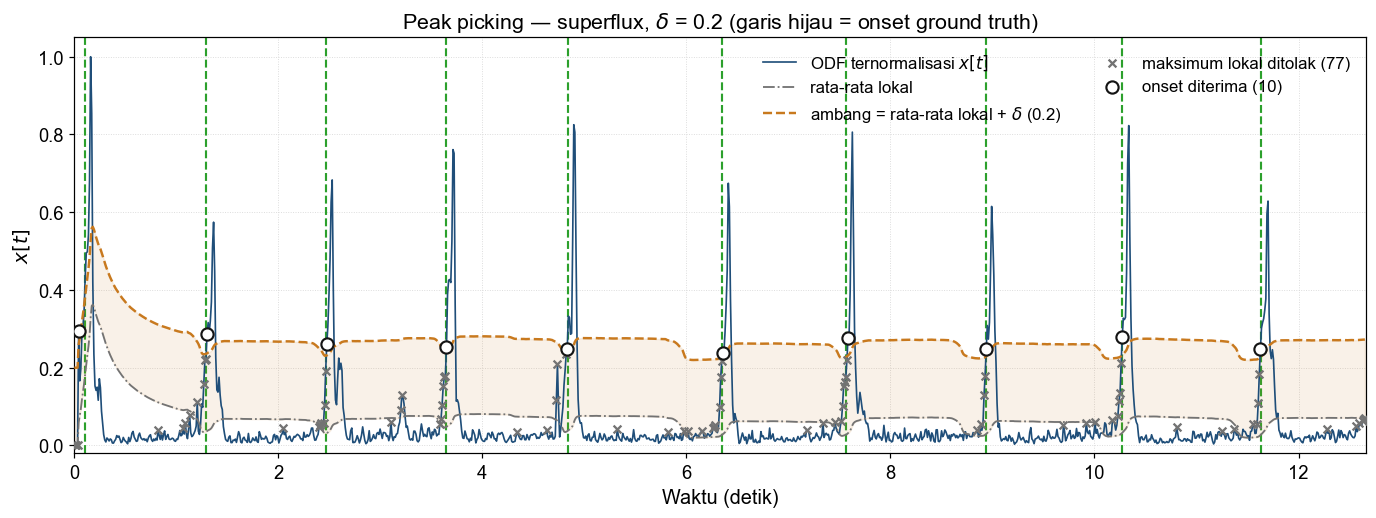

**Sepuluh kandidat pertama yang diuji** (termasuk yang ditolak):

,waktu (detik),x[n],rata-rata lokal,ambang (+delta),selisih,status
frame,,,,,,
1,0.011,0.0000,0.0000,0.2000,-0.2000,ditolak
2,0.021,0.0000,0.0000,0.2000,-0.2000,ditolak
3,0.032,0.0000,0.0000,0.2000,-0.2000,ditolak
4,0.043,0.2954,0.0591,0.2591,0.0363,ONSET
77,0.821,0.0401,0.1109,0.3109,-0.2708,ditolak
100,1.067,0.0437,0.0908,0.2908,-0.2470,ditolak
102,1.088,0.0588,0.0916,0.2916,-0.2328,ditolak
106,1.131,0.0783,0.0887,0.2887,-0.2104,ditolak
113,1.205,0.1113,0.0664,0.2664,-0.1551,ditolak


In [12]:
n_total = x_norm.size
local_avg_curve = np.array([
    x_norm[max(0, n - PEAK_PICK["pre_avg"]): min(n + PEAK_PICK["post_avg"], n_total)].mean()
    for n in range(n_total)
])

fig, ax = plt.subplots(figsize=(12.4, 4.6), layout="constrained")
ax.plot(env_t, x_norm, color=NAVY, lw=1.1, zorder=3, label="ODF ternormalisasi $x[t]$")
ax.plot(env_t, local_avg_curve, color="0.45", lw=1.2, ls="-.", zorder=3,
        label="rata-rata lokal")
ax.plot(env_t, local_avg_curve + DELTA_PILIH, color=ACCENT, lw=1.6, ls="--", zorder=3,
        label=f"ambang = rata-rata lokal + $\\delta$ ({DELTA_PILIH})")
ax.fill_between(env_t, local_avg_curve, local_avg_curve + DELTA_PILIH,
                color=ACCENT, alpha=0.10, zorder=2)

rej = trace[trace.status == "ditolak"]
ax.scatter(rej["waktu (detik)"], x_norm[rej.frame.to_numpy()], s=26, marker="x",
           color="0.45", zorder=5, label=f"maksimum lokal ditolak ({len(rej)})")
ax.scatter(env_t[frames_hit], x_norm[frames_hit], s=64, facecolor="white",
           edgecolors="0.08", linewidths=1.4, zorder=6,
           label=f"onset diterima ({len(frames_hit)})")

for _, ev in annot.iterrows():
    ax.axvline(ev["mulai (detik)"], color="#2ca02c", ls="--", lw=1.4, zorder=1)

ax.set_xlabel("Waktu (detik)"); ax.set_ylabel("$x[t]$")
ax.set_title(f"Peak picking — {ODF_PILIH}, $\\delta$ = {DELTA_PILIH} "
             "(garis hijau = onset ground truth)")
ax.set_xlim(0, duration_s); ax.set_ylim(-0.02, 1.05)
ax.set_axisbelow(True); ax.grid(True, ls=":", lw=0.6, color="0.85")
ax.legend(loc="upper right", ncol=2)
plt.show()

display(Markdown("**Sepuluh kandidat pertama yang diuji** (termasuk yang ditolak):"))
display(trace.head(10).set_index("frame"))

### 7.4 Pengaruh nilai $\delta$

$\delta$ menentukan keseimbangan *recall* dan *precision*: nilai kecil menerima lebih banyak
puncak (*onset* palsu bertambah), nilai besar hanya menerima puncak yang sangat menonjol
(*onset* terlewat). Tabel berikut menghitung ulang deteksi untuk seluruh nilai $\delta$ yang
diuji pada Bab IV, dibandingkan terhadap 10 *onset* *ground truth* berkas ini dengan jendela
toleransi 50 ms.

*Ground truth* berkas ini: **10 onset**

terdeteksi  cocok  precision  recall  f-measure  ME (ms)
ODF           delta                                                          
spectral-flux 0.1            11      7     0.6364     0.7     0.6667   -31.10
              0.2            10      9     0.9000     0.9     0.9000    -8.30
              0.3            10      8     0.8000     0.8     0.8000    23.79
              0.4            10      4     0.4000     0.4     0.4000    42.25
              0.5            10      3     0.3000     0.3     0.3000    47.89
superflux     0.1            10      8     0.8000     0.8     0.8000   -18.29
              0.2            10      9     0.9000     0.9     0.9000     4.74
              0.3            10      9     0.9000     0.9     0.9000    38.89
              0.4            10      4     0.4000     0.4     0.4000    45.33
              0.5            10      2     0.2000     0.2     0.2000    49.17

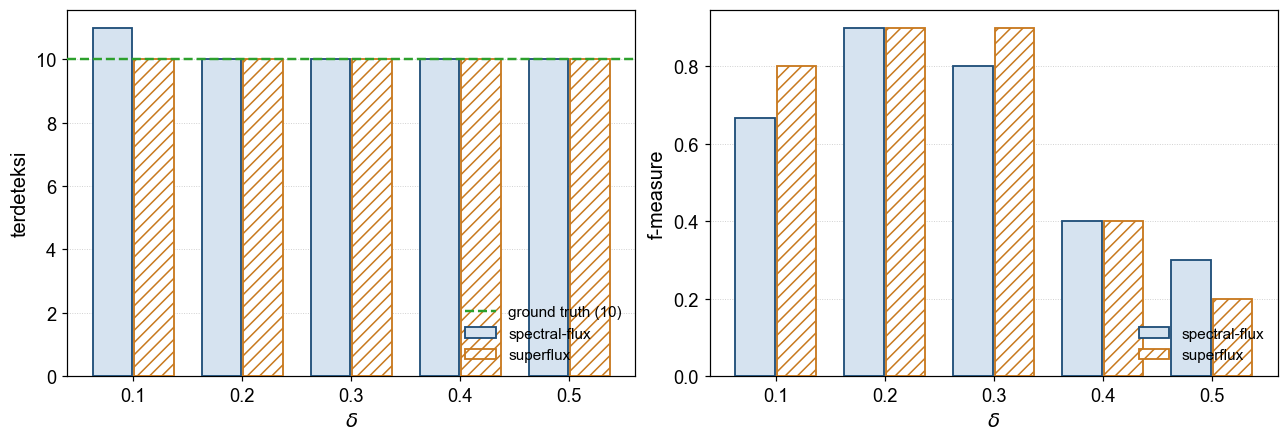

In [13]:
from mir_eval.onset import f_measure as onset_f_measure
from mir_eval.util import match_events

WINDOW_S = 0.05
ref_times = annot["mulai (detik)"].to_numpy(dtype=float)

sweep = []
for name in ODF_KW:
    for delta in DELTAS:
        frames = librosa.onset.onset_detect(
            onset_envelope=envelopes[name], sr=sr, hop_length=CQT_HOP_LENGTH,
            delta=delta, **PEAK_PICK,
        )
        est = librosa.frames_to_time(frames, sr=sr, hop_length=CQT_HOP_LENGTH)
        f1, prec, rec = onset_f_measure(ref_times, est, window=WINDOW_S)
        matched = match_events(ref_times, est, WINDOW_S) if est.size else []
        err_ms = np.array([est[j] - ref_times[i] for i, j in matched]) * 1000.0
        sweep.append({
            "ODF": name, "delta": delta,
            "terdeteksi": int(est.size), "cocok": len(matched),
            "precision": round(prec, 4), "recall": round(rec, 4),
            "f-measure": round(f1, 4),
            "ME (ms)": round(float(err_ms.mean()), 2) if len(matched) else np.nan,
        })

sweep_df = pd.DataFrame(sweep)
display(Markdown(f"*Ground truth* berkas ini: **{len(ref_times)} onset**"))
display(sweep_df.set_index(["ODF", "delta"]))

BAR_STYLE = {
    "spectral-flux": (-0.19, dict(facecolor=FILL, edgecolor=NAVY)),
    "superflux": (0.19, dict(facecolor="white", edgecolor=ACCENT, hatch="///")),
}

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9), layout="constrained")
xpos = np.arange(len(DELTAS))
for ax, metric in zip(axes, ["terdeteksi", "f-measure"]):
    for name, (offset, style) in BAR_STYLE.items():
        vals = sweep_df.loc[sweep_df.ODF == name, metric].to_numpy()
        ax.bar(xpos + offset, vals, 0.36, linewidth=1.2, zorder=3, label=name, **style)
    if metric == "terdeteksi":
        ax.axhline(len(ref_times), color="#2ca02c", ls="--", lw=1.6, zorder=4,
                   label=f"ground truth ({len(ref_times)})")
    ax.set_xticks(xpos, [f"{d:.1f}" for d in DELTAS])
    ax.set_xlabel("$\\delta$")
    ax.set_ylabel(metric)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, ls=":", lw=0.6, color="0.8")
    ax.legend(loc="lower right", fontsize=10)
plt.show()

## 8. Ringkasan alur

Seluruh tahap yang ditelusuri, dengan bentuk data pada setiap peralihan.

In [14]:
alur = pd.DataFrame([
    ("1. Muat audio", "berkas .ogg",
     f"vektor {y.size:,} sampel", f"mono, {sr:,} Hz, {duration_s:.3f} detik"),
    ("2. Framing", f"{y.size:,} sampel", f"{S_db.shape[1]} frame",
     f"hop {CQT_HOP_LENGTH} sampel = {CQT_HOP_LENGTH / sr * 1000:.2f} ms antar frame"),
    ("3. CQT", f"{y.size:,} sampel", f"{C_complex.shape} kompleks",
     f"Q={Q:.2f}, window {tau_k[-1] * 1000:.0f} ms (bin tertinggi) - {tau_k[0] * 1000:.0f} ms (bin terendah)"),
    ("4. Magnitudo + dB", f"{C_complex.shape} kompleks", f"{S_db.shape} riil",
     "np.abs lalu amplitude_to_db(ref=np.max)"),
    ("5a. Segmen 2 detik", f"{S_db.shape}", f"{seg_feature.shape}",
     f"pad/truncate ke {CQT_FEATURE_FRAMES} frame -> masukan CNN"),
    ("5b. ODF", f"{S_db.shape}", f"({envelopes[ODF_PILIH].size},)",
     f"{ODF_PILIH}: lag={ODF_KW[ODF_PILIH]['lag']}, max_size={ODF_KW[ODF_PILIH]['max_size']}"),
    ("6. Normalisasi", f"({envelopes[ODF_PILIH].size},)", f"({x_norm.size},)",
     "digeser dan diskalakan ke [0, 1]"),
    ("7. Peak picking", f"({x_norm.size},)", f"{len(frames_hit)} onset",
     f"delta={DELTA_PILIH}; {len(trace)} kandidat diuji, {len(trace[trace.status == 'ditolak'])} ditolak"),
], columns=["Tahap", "Masukan", "Keluaran", "Keterangan"]).set_index("Tahap")
display(alur)

hit_times = librosa.frames_to_time(frames_hit, sr=sr, hop_length=CQT_HOP_LENGTH)
matched = dict(match_events(ref_times, hit_times, WINDOW_S))
banding = pd.DataFrame({
    "ground truth (detik)": ref_times.round(3),
    "akor": annot["akor"].to_numpy(),
    "terdeteksi (detik)": [
        round(float(hit_times[matched[i]]), 3) if i in matched else None
        for i in range(len(ref_times))
    ],
})
banding["selisih (ms)"] = [
    round((hit_times[matched[i]] - ref_times[i]) * 1000, 1) if i in matched else None
    for i in range(len(ref_times))
]
banding.index = pd.RangeIndex(1, len(banding) + 1, name="Indeks onset")

f1, prec, rec = onset_f_measure(ref_times, hit_times, window=WINDOW_S)
display(Markdown(
    f"### Hasil akhir — {ODF_PILIH}, $\\delta$ = {DELTA_PILIH}\n\n"
    f"precision **{prec:.4f}** &nbsp;|&nbsp; recall **{rec:.4f}** &nbsp;|&nbsp; "
    f"f-measure **{f1:.4f}** &nbsp;|&nbsp; ME **{banding['selisih (ms)'].mean():.2f} ms** "
    f"(jendela toleransi {WINDOW_S * 1000:.0f} ms)"
))
display(banding)

,Masukan,Keluaran,Keterangan
Tahap,,,
1. Muat audio,berkas .ogg,"vektor 607,680 sampel","mono, 48,000 Hz, 12.660 detik"
2. Framing,"607,680 sampel",1187 frame,hop 512 sampel = 10.67 ms antar frame
3. CQT,"607,680 sampel","(216, 1187) kompleks","Q=51.44, window 25 ms (bin tertinggi) - 1573 m..."
4. Magnitudo + dB,"(216, 1187) kompleks","(216, 1187) riil",np.abs lalu amplitude_to_db(ref=np.max)
5a. Segmen 2 detik,"(216, 1187)","(216, 188)",pad/truncate ke 188 frame -> masukan CNN
5b. ODF,"(216, 1187)","(1187,)","superflux: lag=2, max_size=3"
6. Normalisasi,"(1187,)","(1187,)","digeser dan diskalakan ke [0, 1]"
7. Peak picking,"(1187,)",10 onset,"delta=0.2; 87 kandidat diuji, 77 ditolak"


### Hasil akhir — superflux, $\delta$ = 0.2

precision **0.9000** &nbsp;|&nbsp; recall **0.9000** &nbsp;|&nbsp; f-measure **0.9000** &nbsp;|&nbsp; ME **4.74 ms** (jendela toleransi 50 ms)

,ground truth (detik),akor,terdeteksi (detik),selisih (ms)
Indeks onset,,,,
1,0.101,G:min,NaN,NaN
2,1.294,G:min,1.301,7.3
3,2.469,G:dim,2.475,5.7
4,3.646,G#:dim,3.648,2.0
5,4.835,C#:min,4.832,-3.0
6,6.347,A:min,6.357,10.3
7,7.566,C:dim,7.584,18.0
8,8.936,A:min,8.939,2.7
9,10.268,F#:dim,10.272,4.0


### Catatan atas hasil di atas

**1. Onset pertama tidak tercocokkan.** *Onset* ke-1 dianotasi pada 0,101 s, sedangkan
*peak picking* menempatkannya pada 0,043 s — selisih 58 ms, sedikit di luar jendela toleransi
50 ms, sehingga dihitung sebagai *false negative* sekaligus *false positive* dan menurunkan
*f-measure* menjadi 0,9000. Penyebabnya, serangan nada pertama muncul saat berkas masih
diawali senyap sehingga rata-rata lokal $x$ pada awal deret masih sangat rendah dan puncak
lolos lebih cepat. Sembilan *onset* lainnya tercocokkan dengan simpangan **−4,3 sampai
+18,0 ms**, jauh di dalam toleransi.

**2. Angka pada notebook ini berlaku untuk satu berkas.** Nilai $\delta$ yang dipakai pada
Bab IV (*spectral flux* 0,3 dan *SuperFlux* 0,2) dipilih dari `onset-grid.ipynb` yang menguji
seluruh 60 berkas pada tiga *dataset* evaluasi (620 *onset*), bukan dari satu contoh. Tabel
$\delta$ di atas hanya memperagakan **mekanismenya**: makin besar $\delta$, makin sedikit
puncak yang lolos, dan deteksi cenderung bergeser terlambat (ME berubah dari negatif ke
positif).

**3. Parameter jendela dinyatakan dalam *frame*.** `pre_max`, `pre_avg`, dan `wait` bernilai
30, 100, dan 30 **frame** (bukan milidetik), setara 320 ms, 1067 ms, dan 320 ms. Jendela
`wait` sebesar 320 ms inilah yang mencegah satu serangan nada terhitung berkali-kali, dan
sekaligus membatasi *onset* terdekat yang masih dapat dibedakan sistem.